In [86]:
!pip install -q mne
import scipy.io
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, welch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import mne
from mne import Epochs, find_events

# File paths
file_paths = [
    "/content/drive/MyDrive/A01.mat",
    "/content/drive/MyDrive/A02.mat",
    "/content/drive/MyDrive/A03.mat",
    "/content/drive/MyDrive/A04.mat",
    "/content/drive/MyDrive/A05.mat",
    "/content/drive/MyDrive/A06.mat",
    "/content/drive/MyDrive/A07.mat",
    "/content/drive/MyDrive/A08.mat"
]

# Dictionary to store extracted data
extracted_data = {}

for file_path in file_paths:
    mat_data = scipy.io.loadmat(file_path)
    data = mat_data['data']  # Extract structured array
    channels_temp = (data[0][0][0]).flatten()
    channels = []

    for i in range(8):
        channels.append(channels_temp[i][0])

    X = data[0][0][1]
    y = data[0][0][2].flatten()
    y_stim = data[0][0][3]
    trial = data[0][0][4].flatten()
    classes = data[0][0][5]
    classes_stim = data[0][0][6]
    gender = data[0][0][7]
    age = data[0][0][8]
    ALSfrs = data[0][0][9]
    onsetALS = data[0][0][10]

    info = mne.create_info(channels, sfreq=256, ch_types=['eeg']*8)
    #raw = mne.io.RawArray(X.T, info)
    X_volts = X * 1e-6  # Convert µV to volts for MNE
    raw = mne.io.RawArray(X_volts.T, info)
    raw.set_montage("standard_1020")
    info = mne.create_info(['STI'], raw.info['sfreq'], ['stim'])
    stim_raw = mne.io.RawArray(np.reshape(y, (-1, 1)).T, info)
    raw.add_channels([stim_raw], force_update_info=True)

    # Store in dictionary
    extracted_data[file_path] = {
        "X": X,  # Full EEG matrix
        "Y": y,
        "Y_stim": y_stim,
        "Trial": trial,
        "Channels": channels,
        "Classes": classes,
        "Classes_stim": classes_stim,
        "Raw": raw,
        "Metadata": {
            "Gender": gender,
            "Age": age,
            "ALSfrs": ALSfrs,
            "OnsetALS": onsetALS
        }
    }



#Verify that Y contains only {0, 1}
unique_classes, counts = np.unique(extracted_data[file_paths[0]]["Y"], return_counts=True)
print(f"Y classes: {dict(zip(unique_classes, counts))}")
#Verify that Y contains only {0, 1}
unique_classes1, counts1 = np.unique(extracted_data[file_paths[0]]["Y_stim"], return_counts=True)
print(f"Y_stim classes: {dict(zip(unique_classes1, counts1))}")






Y classes: {np.uint8(0): np.int64(213304), np.uint8(1): np.int64(112000), np.uint8(2): np.int64(22400)}
Y_stim classes: {np.int16(0): np.int64(213304), np.int16(1): np.int64(11200), np.int16(2): np.int64(11200), np.int16(3): np.int64(11200), np.int16(4): np.int64(11200), np.int16(5): np.int64(11200), np.int16(6): np.int64(11200), np.int16(7): np.int64(11200), np.int16(8): np.int64(11200), np.int16(9): np.int64(11200), np.int16(10): np.int64(11200), np.int16(11): np.int64(11200), np.int16(12): np.int64(11200)}


In [87]:
from scipy.signal import butter, filtfilt

# Apply bandpass filter to EEG data
filtered_data = {}

for file_path, data in extracted_data.items():
    if data["Raw"] is not None:
        raw = data["Raw"]


        #Filter using bandpass filter
        filtered_raw = raw.copy().filter(5, 30, picks='eeg', method='iir', iir_params=dict(order=8, ftype='butter'), verbose=True) # Apply filter to EEG data

        #Filter using notch filter at 60Hz
        filtered_raw.notch_filter(freqs=[60], picks='eeg', verbose=True)

        #Generate Epochs
        events = find_events(filtered_raw)
        #epochs = Epochs(filtered_raw, events, dict(NT=1, T=2), -0.2, 0.8, picks='eeg', baseline=(-0.2, 0), reject=None, preload=True)

        #Epochs
        epochs = Epochs(filtered_raw, events, dict(NT=1, T=2), -0.2, 0.8, picks='eeg', baseline=(-0.2, 0), reject=None, preload=True)

        labels = np.where(epochs.events[:, 2] == 2, 1, 0)

        filtered_data[file_path] = {
            "X": data["X"],
            "Y": data["Y"],
            "Y_stim": data["Y_stim"],
            "labels": labels,
            "Trial": data["Trial"],
            "Channels": data["Channels"],
            "Classes": data["Classes"],
            "Classes_stim": data["Classes_stim"],
            "Raw": data["Raw"],
            "Filtered_Raw": filtered_raw,
            "Epochs": epochs,
            "Metadata": data["Metadata"]
        }

# Check filtered EEG signals from the first file
filtered_data[file_paths[0]]


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 5 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 32 (effective, after forward-backward)
- Cutoffs at 5.00, 30.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 5 - 30 Hz

IIR filter parameters
--------------

{'X': array([[ -1.21978372,  -0.32769319,  -1.21995831, ...,  -2.65680554,
           7.37202505,  -0.27890203],
        [ -1.42616224,  -4.18996393,  -5.65458822, ...,  -9.45534598,
          -3.67053188,  -5.48506363],
        [ -1.31524453,  -6.87075831,  -8.55992067, ..., -14.26798757,
         -11.63200572,  -8.92900433],
        ...,
        [ -3.96511643,   5.70748743,   1.11047492, ...,  -5.27998942,
           9.13724881,  -0.85580654],
        [ -0.5562302 ,   6.01519786,   3.32213104, ...,  -0.67030739,
           8.2749988 ,   2.10576813],
        [  4.22622461,   6.77563943,   6.12924025, ...,   5.20342677,
           6.29436858,   6.15256883]]),
 'Y': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
 'Y_stim': array([[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]], dtype=int16),
 'labels': array([0, 0, 0, ..., 0, 0, 0]),
 'Trial': array([  1801,  11529,  21257,  30985,  40713,  51473,  61201,  70929,
         80657,  90385, 101145, 110873, 1

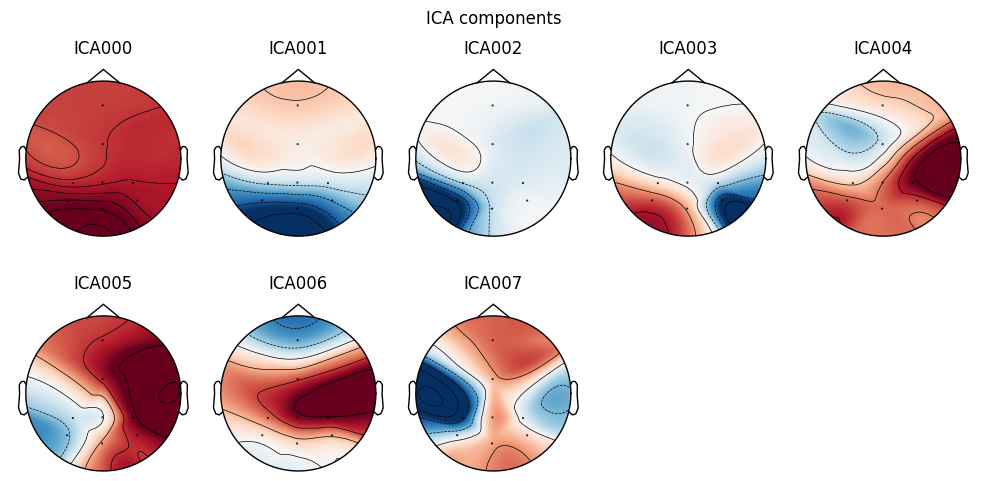

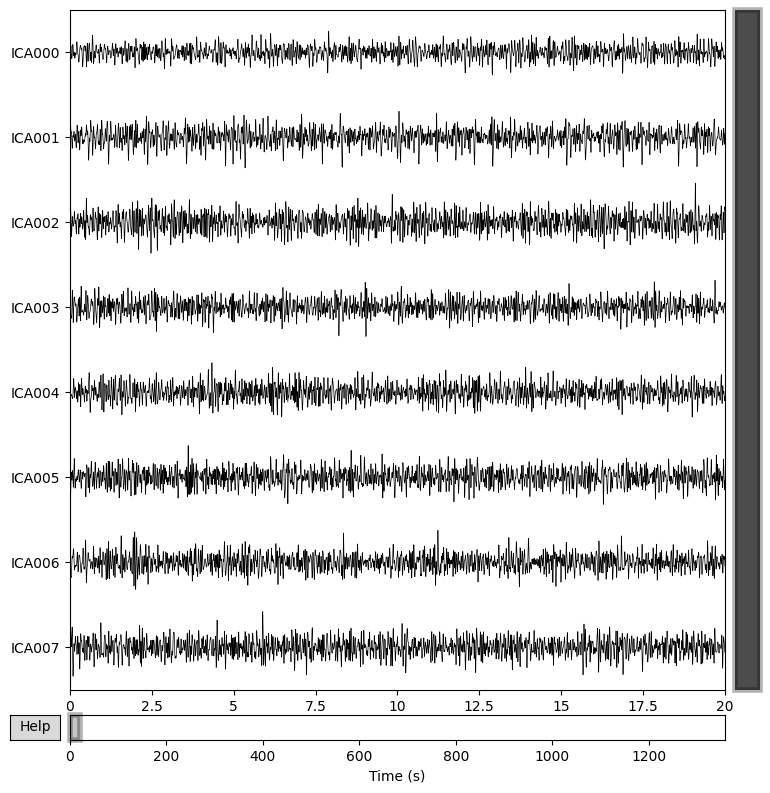

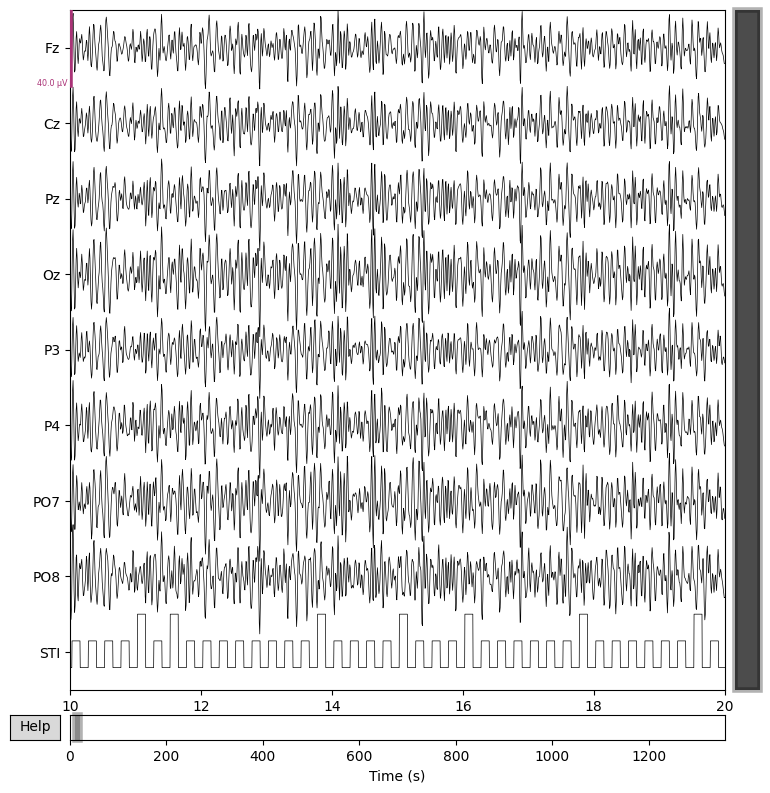

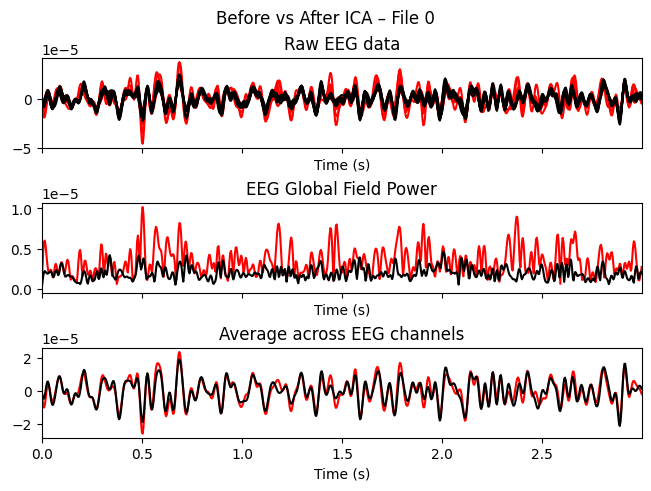

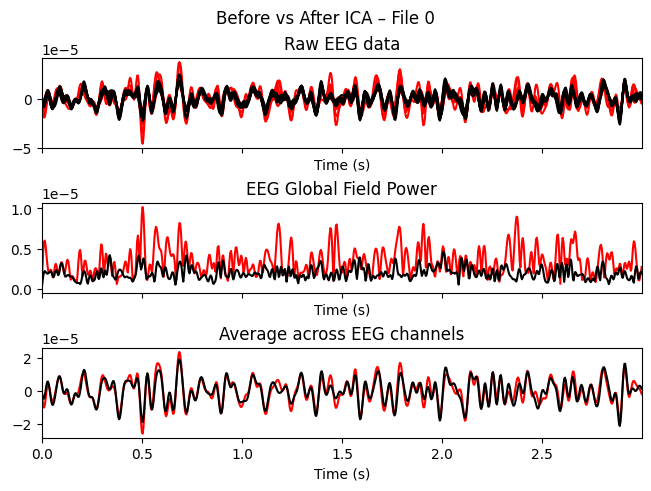

In [78]:
#Manual ICA
test = filtered_data[file_paths[0]]

filtered_raw = test["Filtered_Raw"]

from mne.preprocessing import ICA, create_eog_epochs

# 1. Fit ICA
ica = ICA(n_components=None, random_state=97, method='fastica')
ica.fit(filtered_raw)

# 2. Manually inspect ICA components
ica.plot_components()  # Opens interactive GUI to visually inspect components
ica.plot_sources(filtered_raw)  # View time courses of components

#3. Manually set bad components after inspection
ica.exclude = [1,2]  # ← Replace with components you want to exclude based on visual inspection

filtered_raw_ica = ica.apply(filtered_raw.copy())
filtered_data[file_paths[0]]["Filtered_Raw_ICA"] = filtered_raw_ica
filtered_data[file_paths[0]]["ICA_Excluded"] = ica.exclude


filtered_raw_ica.plot(start=10, duration=10, title="EEG After ICA – File 0")
ica.plot_overlay(filtered_raw, title="Before vs After ICA – File 0")


In [99]:
manual_ica_exclusions = {
    file_paths[0]: [1, 2],
    file_paths[1]: [1,2,3],
    file_paths[2]: [1, 6],
    file_paths[3]: [2, 3],
    file_paths[4]: [2],
    file_paths[5]: [4],
    file_paths[6]: [1,2, 4,6],
    file_paths[7]: [1,2,4],  # Add more if needed
}

from mne.preprocessing import ICA
import matplotlib.pyplot as plt

for file_path in file_paths:
    try:
        filtered_raw = filtered_data[file_path]["Filtered_Raw"].copy()

        # 1. Fit ICA
        ica = ICA(n_components=None, random_state=97, method='fastica')
        ica.fit(filtered_raw)

        # 2. Manually set bad components
        exclude = manual_ica_exclusions.get(file_path, [])  # default to empty if not found
        ica.exclude = exclude

        # 3. Apply ICA
        filtered_raw_ica = ica.apply(filtered_raw.copy())

        # 4. Store ICA-cleaned data
        filtered_data[file_path]["Filtered_Raw_ICA"] = filtered_raw_ica
        filtered_data[file_path]["ICA_Excluded"] = exclude

        print(f"✅ ICA applied for {file_path} | Excluded: {exclude}")


    except Exception as e:
        print(f"❌ ICA failed for {file_path}: {e}")


✅ ICA applied for /content/drive/MyDrive/A01.mat | Excluded: [1, 2]
✅ ICA applied for /content/drive/MyDrive/A02.mat | Excluded: [1, 2, 3]
✅ ICA applied for /content/drive/MyDrive/A03.mat | Excluded: [1, 6]
✅ ICA applied for /content/drive/MyDrive/A04.mat | Excluded: [2, 3]
✅ ICA applied for /content/drive/MyDrive/A05.mat | Excluded: [2]
✅ ICA applied for /content/drive/MyDrive/A06.mat | Excluded: [4]
✅ ICA applied for /content/drive/MyDrive/A07.mat | Excluded: [1, 2, 4, 6]
✅ ICA applied for /content/drive/MyDrive/A08.mat | Excluded: [1, 2, 4]


In [89]:
from mne import find_events, Epochs
import numpy as np

for file_path in file_paths:
    try:
        raw = filtered_data[file_path]["Filtered_Raw_ICA"]

        # Find events again
        events = find_events(raw)

        # Create new epochs from ICA-cleaned raw
        epochs = Epochs(
            raw,
            events=events,
            event_id=dict(NT=1, T=2),
            tmin=-0.2,
            tmax=0.8,
            picks="eeg",
            baseline=(-0.2, 0),
            preload=True,
            reject=None
        )

        # Update labels (1 = target, 0 = non-target)
        labels = np.where(epochs.events[:, 2] == 2, 1, 0)

        # Store updated epochs and labels
        filtered_data[file_path]["Epochs"] = epochs
        filtered_data[file_path]["labels"] = labels

        print(f"✅ Epochs regenerated for: {file_path}")

    except Exception as e:
        print(f"❌ Failed to epoch {file_path}: {e}")

✅ Epochs regenerated for: /content/drive/MyDrive/A01.mat
✅ Epochs regenerated for: /content/drive/MyDrive/A02.mat
✅ Epochs regenerated for: /content/drive/MyDrive/A03.mat
✅ Epochs regenerated for: /content/drive/MyDrive/A04.mat
✅ Epochs regenerated for: /content/drive/MyDrive/A05.mat
✅ Epochs regenerated for: /content/drive/MyDrive/A06.mat
✅ Epochs regenerated for: /content/drive/MyDrive/A07.mat
✅ Epochs regenerated for: /content/drive/MyDrive/A08.mat


In [75]:
import matplotlib.pyplot as plt

test = filtered_data[file_paths[0]]

X = test["X"]
filtered_raw = test["Filtered_Raw"]
labels = test["labels"]
Y = test["Y"]
epochs = test["Epochs"]
print("epochs:",epochs)

print("X:",X.shape)

print("labels:",labels.shape)
print("Y:",Y.shape)

epochs: <Epochs | 4200 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~65.9 MiB, data loaded,
 'NT': 3500
 'T': 700>
X: (347704, 8)
labels: (4200,)
Y: (347704,)


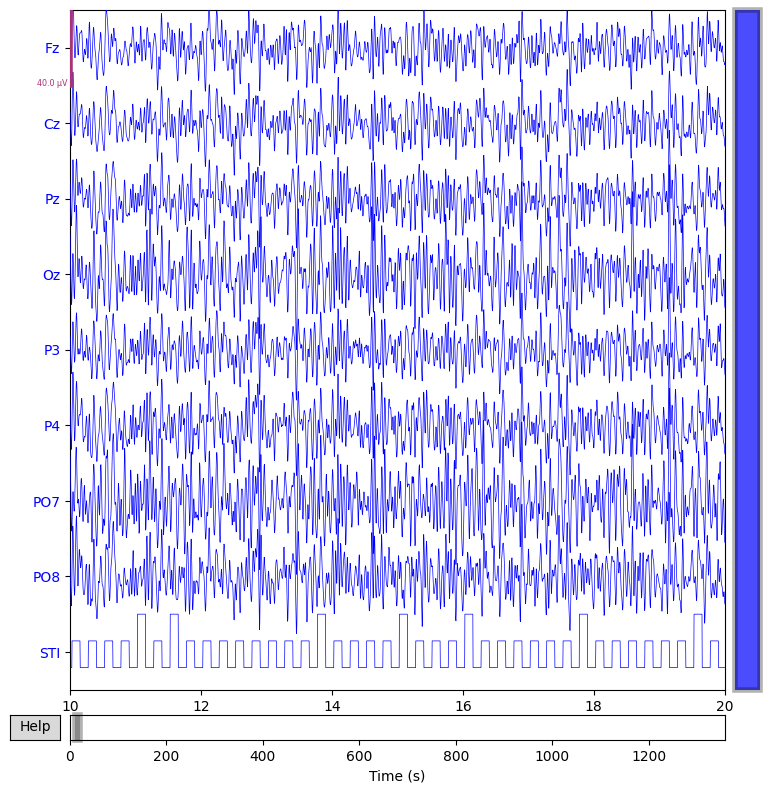

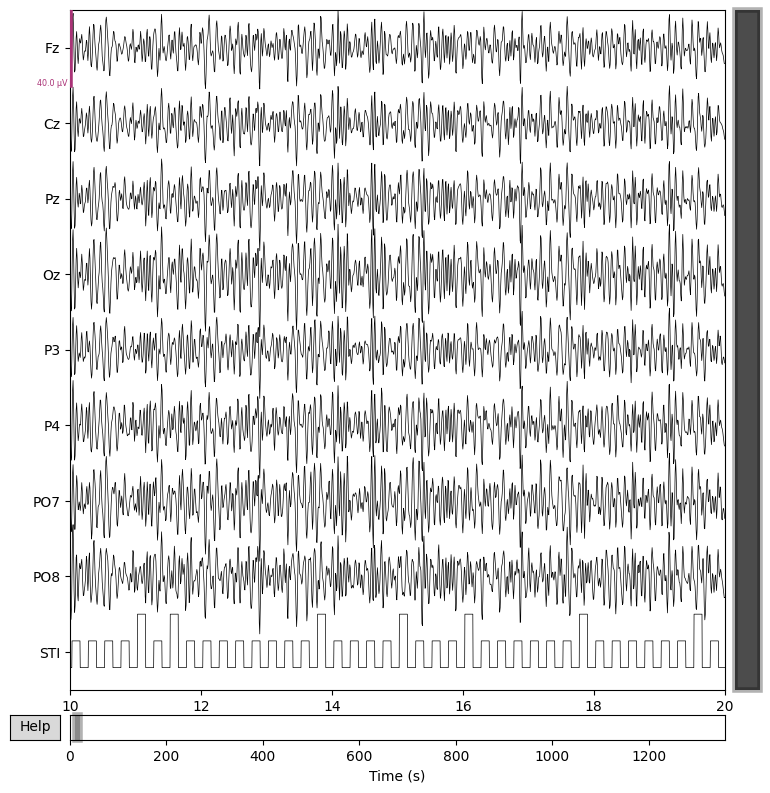

In [100]:
#Visualize the Raw and Filtered_raw data
test = filtered_data[file_paths[0]]
raw = test["Raw"]
filtered_raw = test["Filtered_Raw_ICA"]

plot_raw = raw.plot(color = 'blue', duration =10 ,start = 10,
                        title = "Raw EEG signals", show_scalebars=True, show_scrollbars=True)
plot_filt = filtered_raw.plot(color = 'black', duration =10 ,start = 10, show_scalebars=True, show_scrollbars=True)


In [93]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch
def extract_time_and_stat_features(epochs, sfreq=256):

    data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
    n_epochs, n_channels, n_times = data.shape

    # Define time windows relative to stim onset (assuming tmin = -0.2s)
    stim_index = int(0.2 * sfreq)               # index for time 0 (stim onset)
    idx_min_100_250 = (stim_index + int(0.1 * sfreq), stim_index + int(0.25 * sfreq))
    idx_max_250_500 = (stim_index + int(0.25 * sfreq), stim_index + int(0.5 * sfreq))
    idx_auc_250_500 = idx_max_250_500

    feature_matrix = []

    for epoch in data:
        epoch_features = []
        for ch_data in epoch:
            # --- ERP Features ---
            min_pre = np.min(ch_data[idx_min_100_250[0]:idx_min_100_250[1]])
            max_p300 = np.max(ch_data[idx_max_250_500[0]:idx_max_250_500[1]])
            peak_feature = max_p300 - min_pre
            area_feature = np.sum(ch_data[idx_auc_250_500[0]:idx_auc_250_500[1]])

            # --- Statistical Features (over full epoch or selected window) ---
            signal = ch_data[stim_index:]  # You can use full post-stim window or entire epoch

            mean_val = np.mean(signal)
            var_val = np.var(signal)
            skew_val = skew(signal)
            kurt_val = kurtosis(signal)
            rms_val = np.sqrt(np.mean(signal**2))

            # Combine all features
            epoch_features.extend([
                peak_feature,
                area_feature,
                mean_val,
                var_val,
                skew_val,
                kurt_val,
                rms_val
            ])

        feature_matrix.append(epoch_features)

    return np.array(feature_matrix)



for file_path, data in filtered_data.items():
    if data["Epochs"] is not None:
        epochs = data["Epochs"]
        time_domain_features = extract_time_and_stat_features(epochs)


        filtered_data[file_path]["Time_Domain_Features"] = time_domain_features

# Check filtered EEG signals from the first file
filtered_data[file_paths[0]]



{'X': array([[ -1.21978372,  -0.32769319,  -1.21995831, ...,  -2.65680554,
           7.37202505,  -0.27890203],
        [ -1.42616224,  -4.18996393,  -5.65458822, ...,  -9.45534598,
          -3.67053188,  -5.48506363],
        [ -1.31524453,  -6.87075831,  -8.55992067, ..., -14.26798757,
         -11.63200572,  -8.92900433],
        ...,
        [ -3.96511643,   5.70748743,   1.11047492, ...,  -5.27998942,
           9.13724881,  -0.85580654],
        [ -0.5562302 ,   6.01519786,   3.32213104, ...,  -0.67030739,
           8.2749988 ,   2.10576813],
        [  4.22622461,   6.77563943,   6.12924025, ...,   5.20342677,
           6.29436858,   6.15256883]]),
 'Y': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
 'Y_stim': array([[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]], dtype=int16),
 'labels': array([0, 0, 0, ..., 0, 0, 0]),
 'Trial': array([  1801,  11529,  21257,  30985,  40713,  51473,  61201,  70929,
         80657,  90385, 101145, 110873, 1

epochs: <Epochs | 4200 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~65.9 MiB, data loaded,
 'NT': 3500
 'T': 700>
features: (4200, 56)
X: (347704, 8)
labels: (4200,)
Y: (347704,)


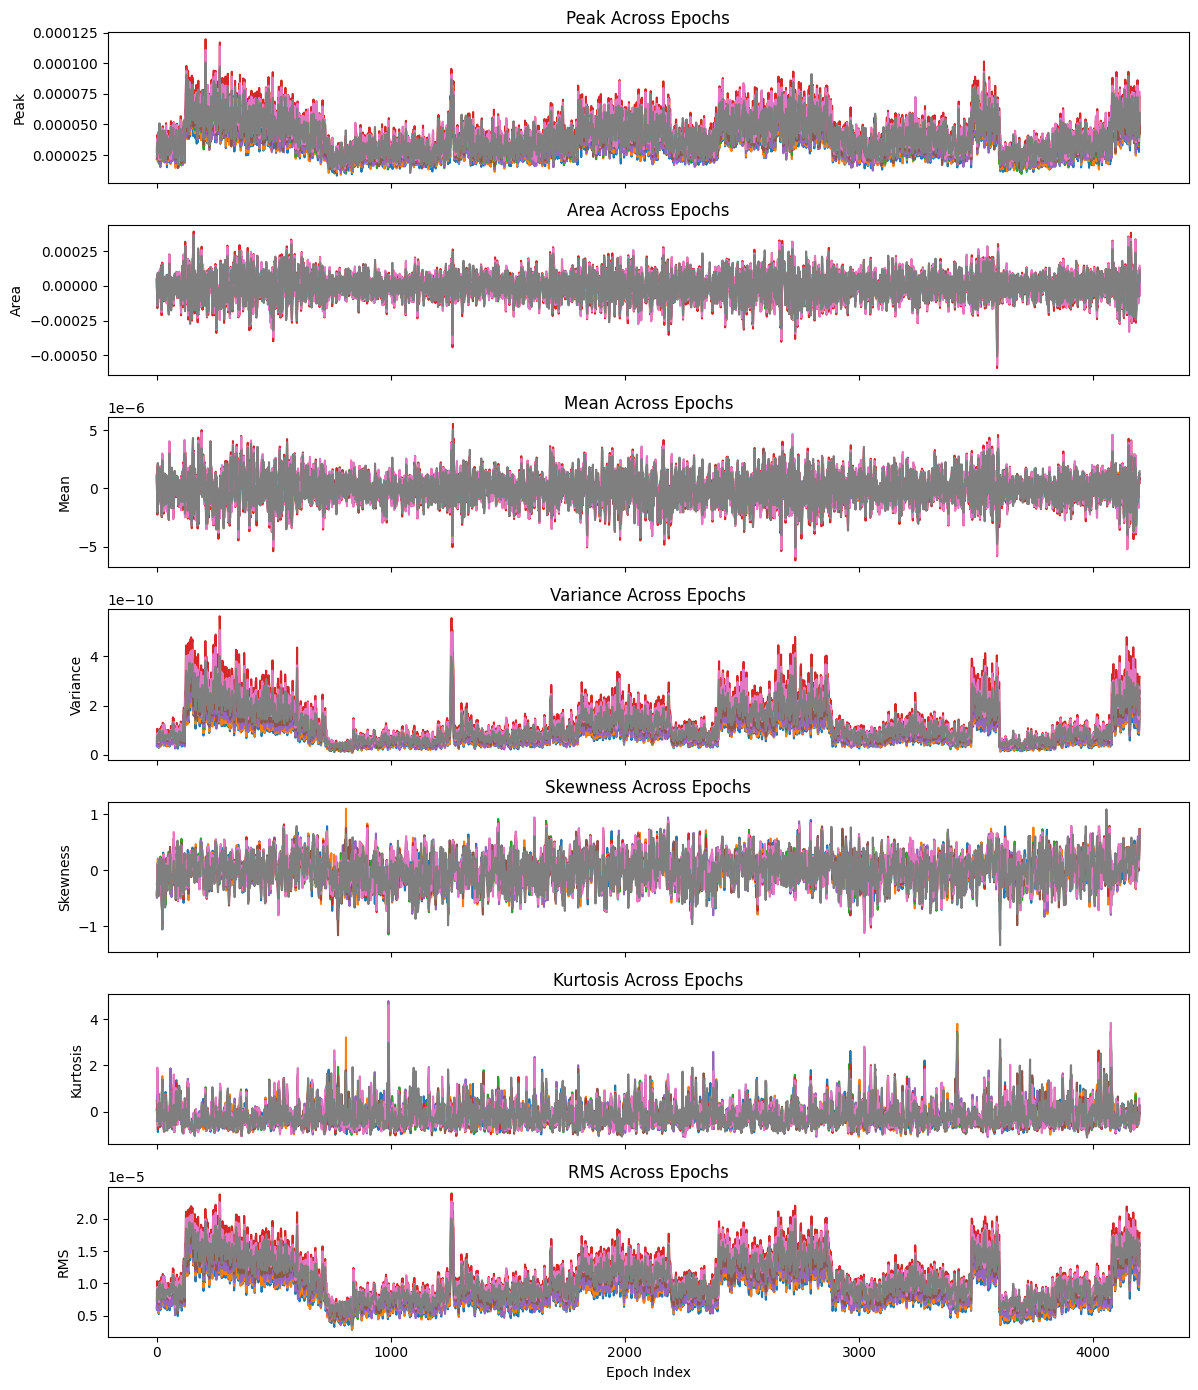

In [94]:
import matplotlib.pyplot as plt

test = filtered_data[file_paths[0]]
features = test["Time_Domain_Features"]
X = test["X"]
filtered_raw = test["Filtered_Raw"]
labels = test["labels"]
Y = test["Y"]
epochs = test["Epochs"]
print("epochs:",epochs)
print("features:",features.shape)
print("X:",X.shape)
#print("filtered_raw:",filtered_raw.shape)
print("labels:",labels.shape)
print("Y:",Y.shape)

import matplotlib.pyplot as plt

# Parameters
n_features_per_channel = 7
feature_names = ['Peak', 'Area', 'Mean', 'Variance', 'Skewness', 'Kurtosis', 'RMS']
n_channels = features.shape[1] // n_features_per_channel
n_epochs = features.shape[0]

# Reshape: (n_epochs, n_channels, n_features_per_channel)
features_reshaped = features.reshape(n_epochs, n_channels, n_features_per_channel)

# Plot each feature across epochs (one subplot per feature type)
fig, axs = plt.subplots(n_features_per_channel, 1, figsize=(12, 14), sharex=True)

for i, name in enumerate(feature_names):
    feature_data = features_reshaped[:, :, i]  # shape: (n_epochs, n_channels)
    axs[i].plot(feature_data)
    axs[i].set_title(f"{name} Across Epochs")
    axs[i].set_ylabel(name)

axs[-1].set_xlabel("Epoch Index")
plt.tight_layout()
plt.show()

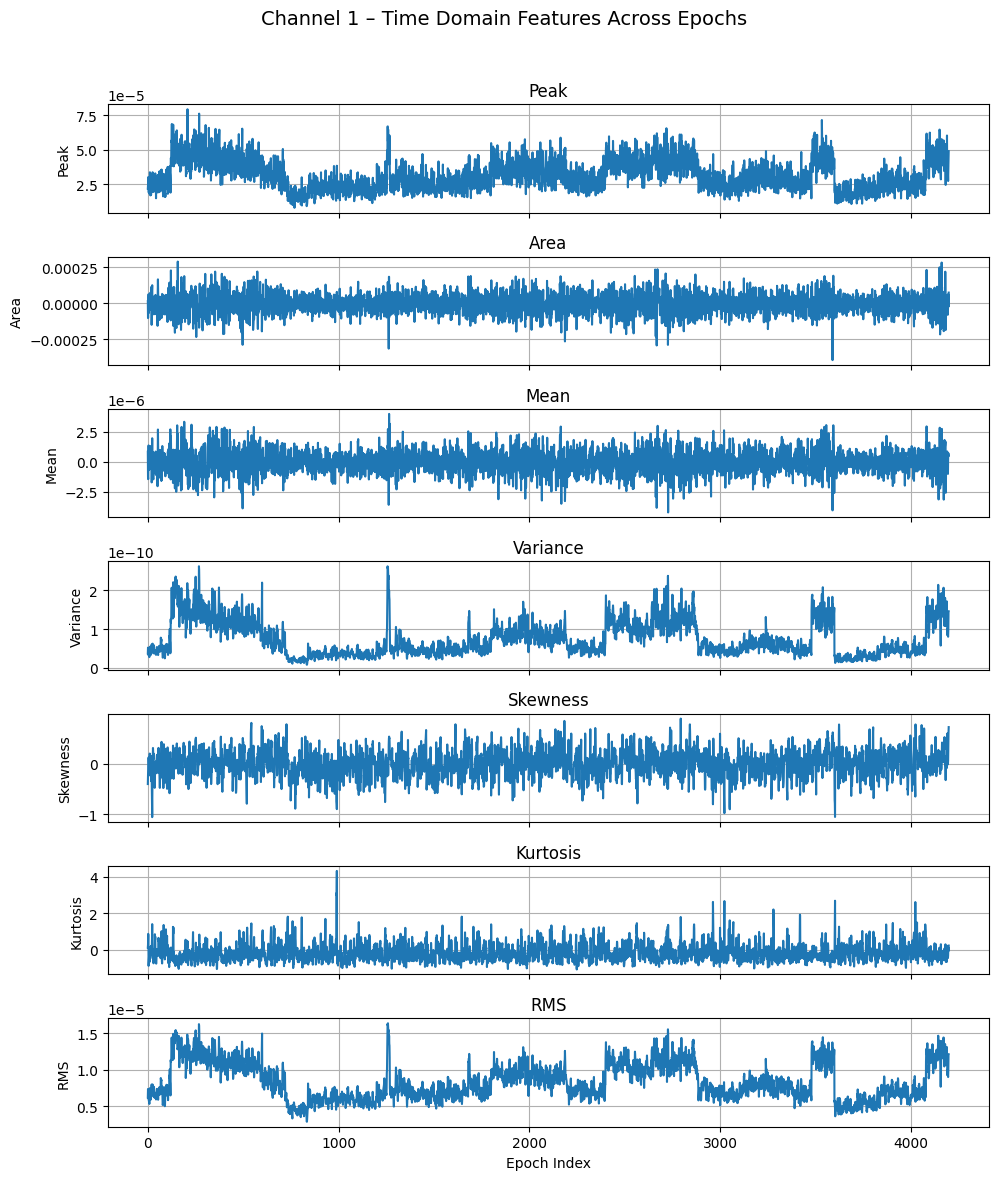

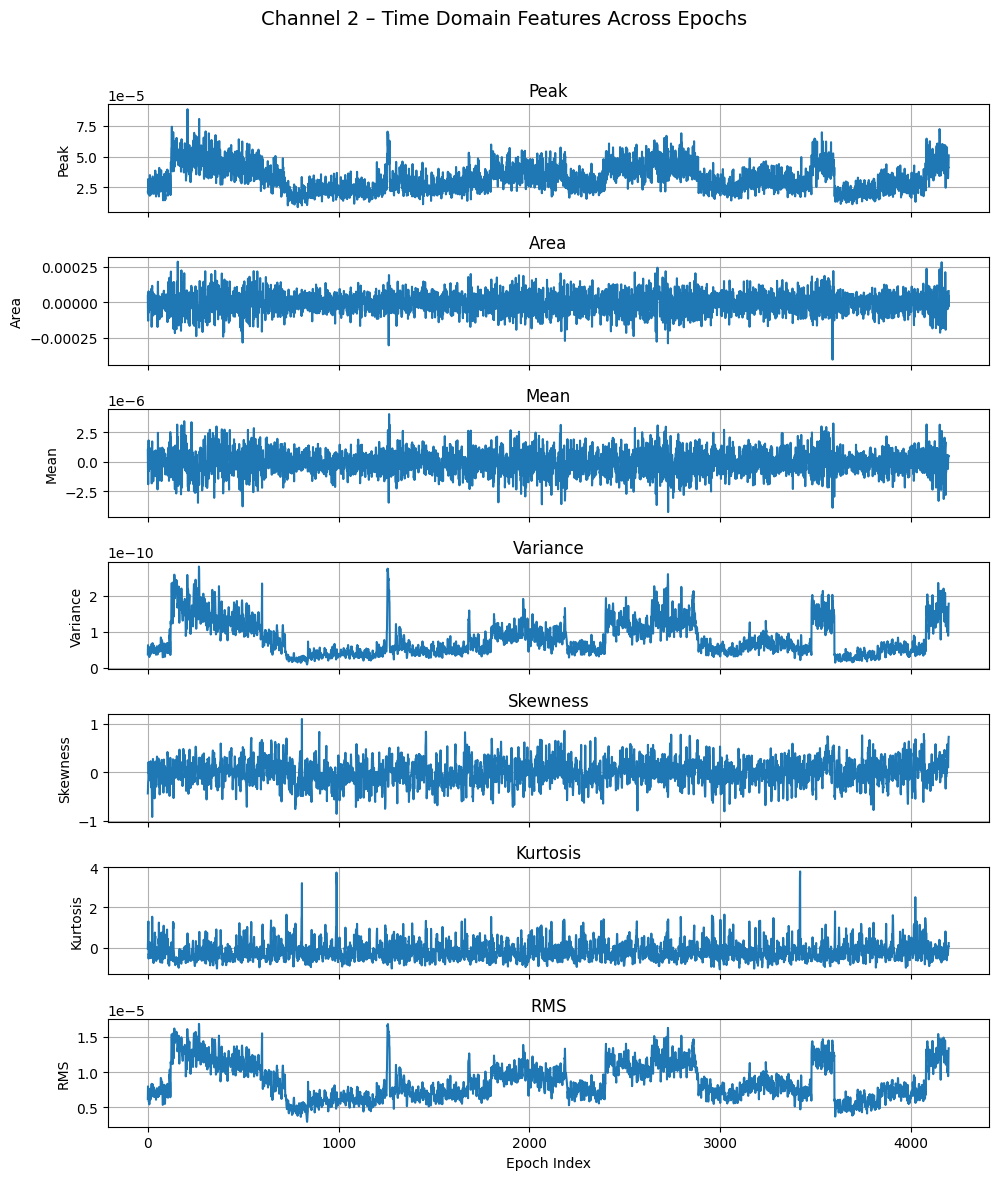

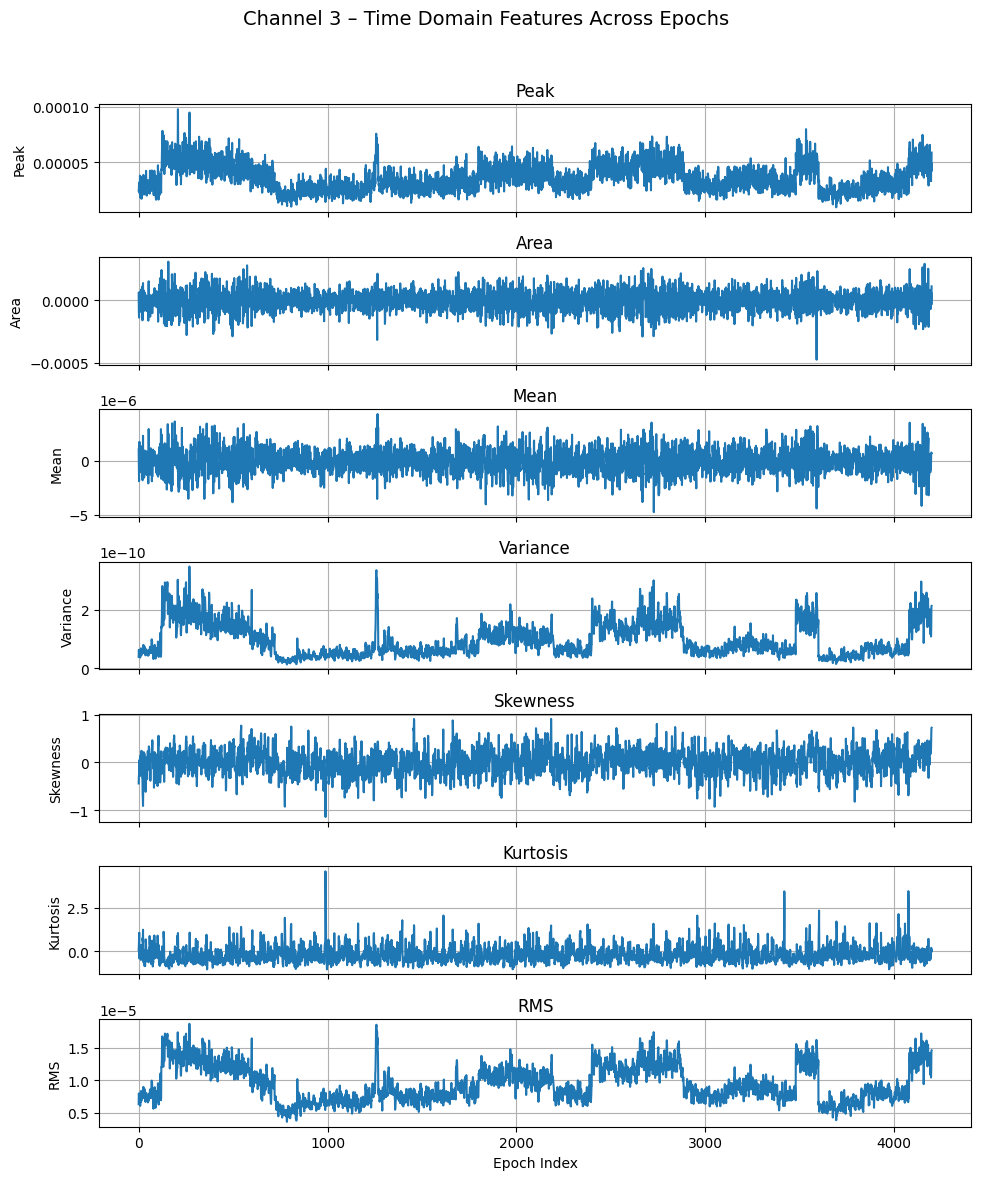

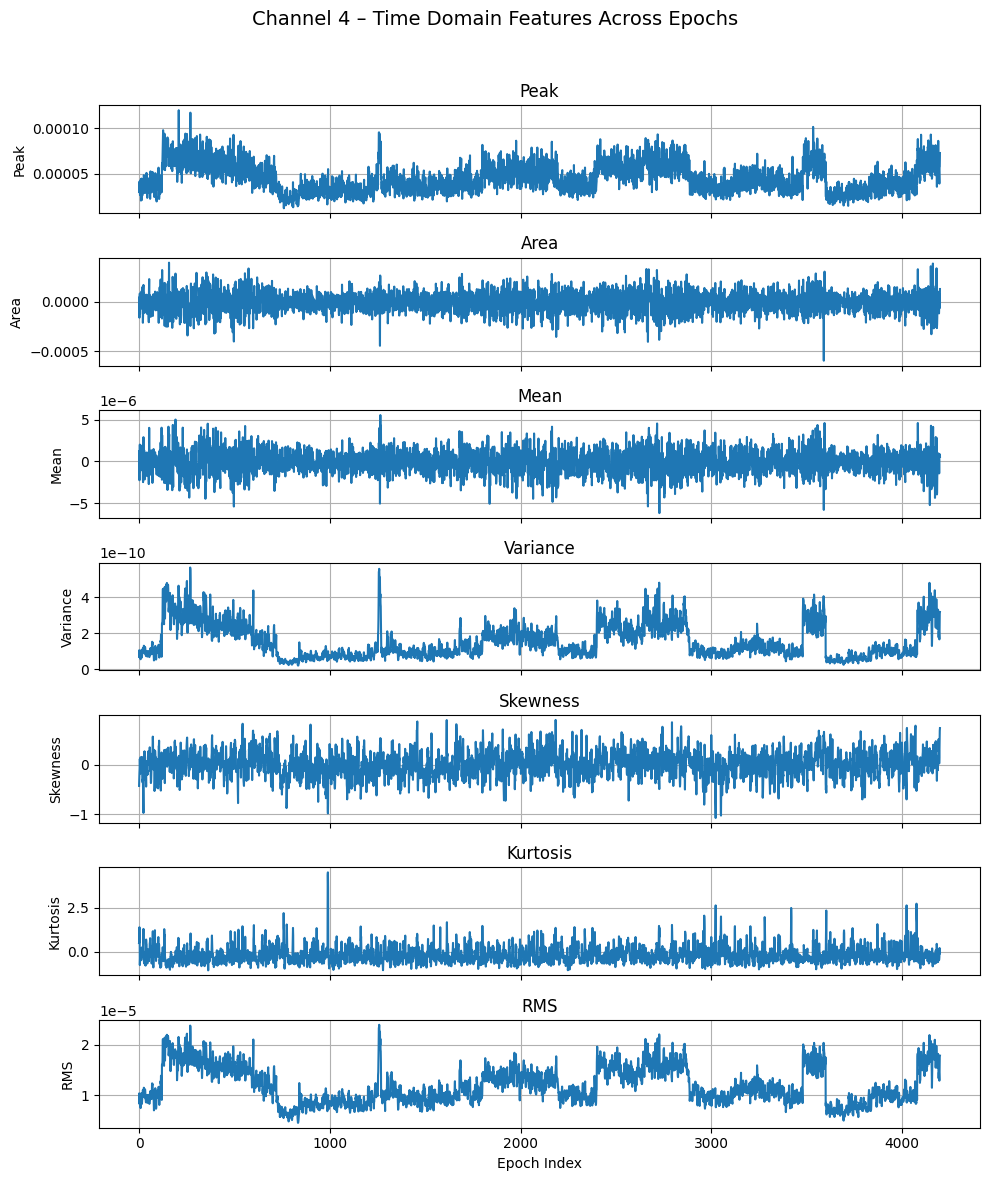

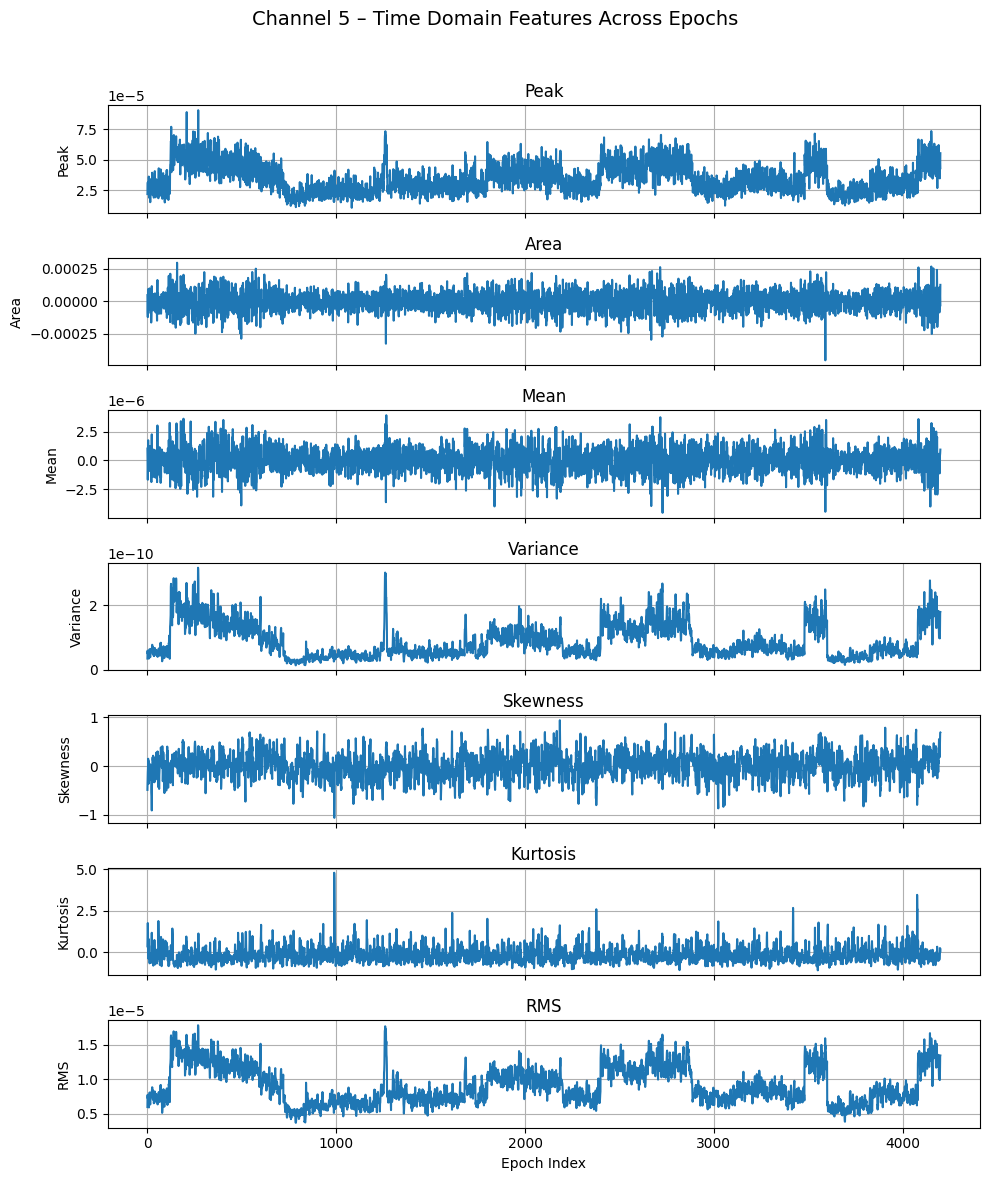

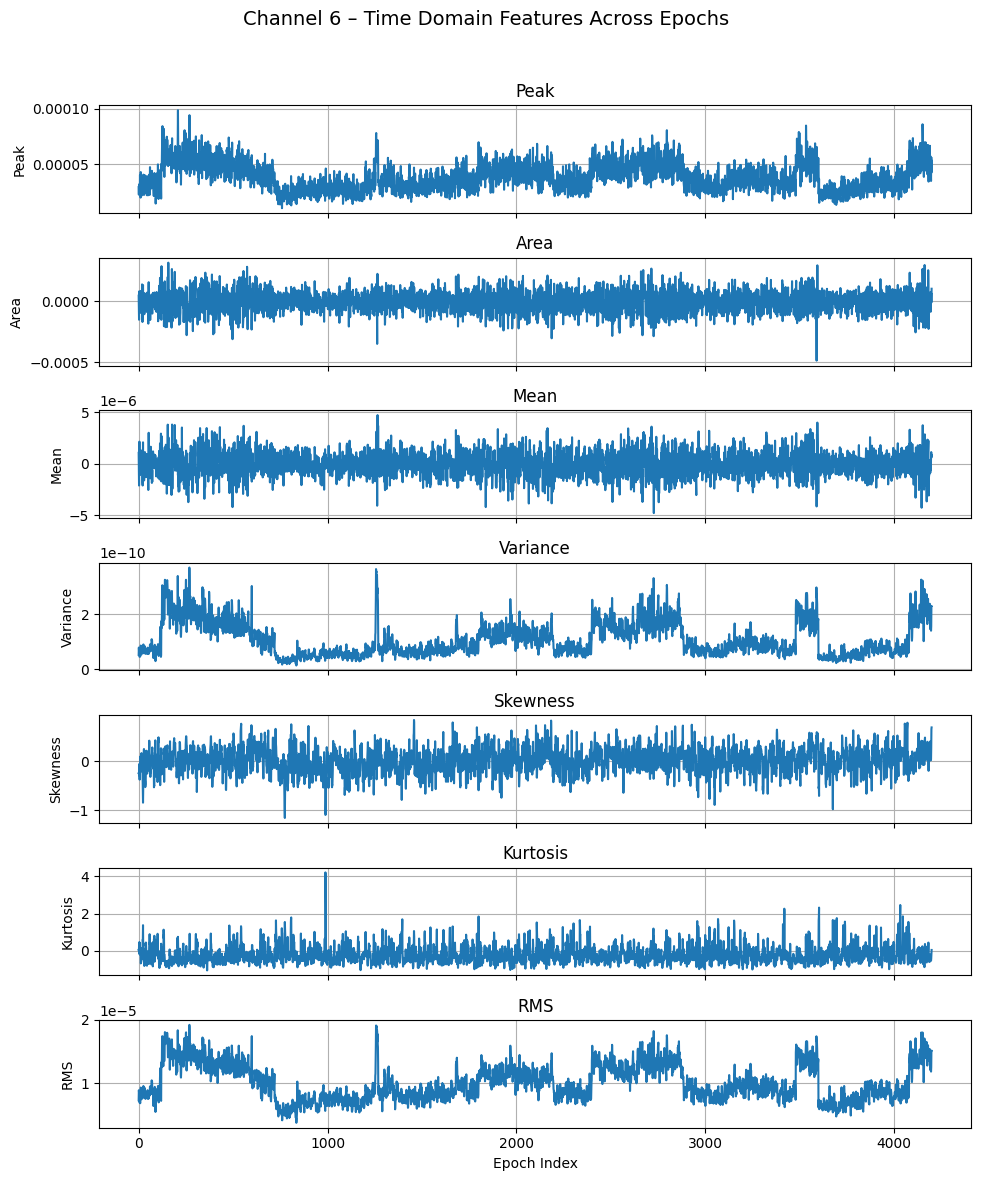

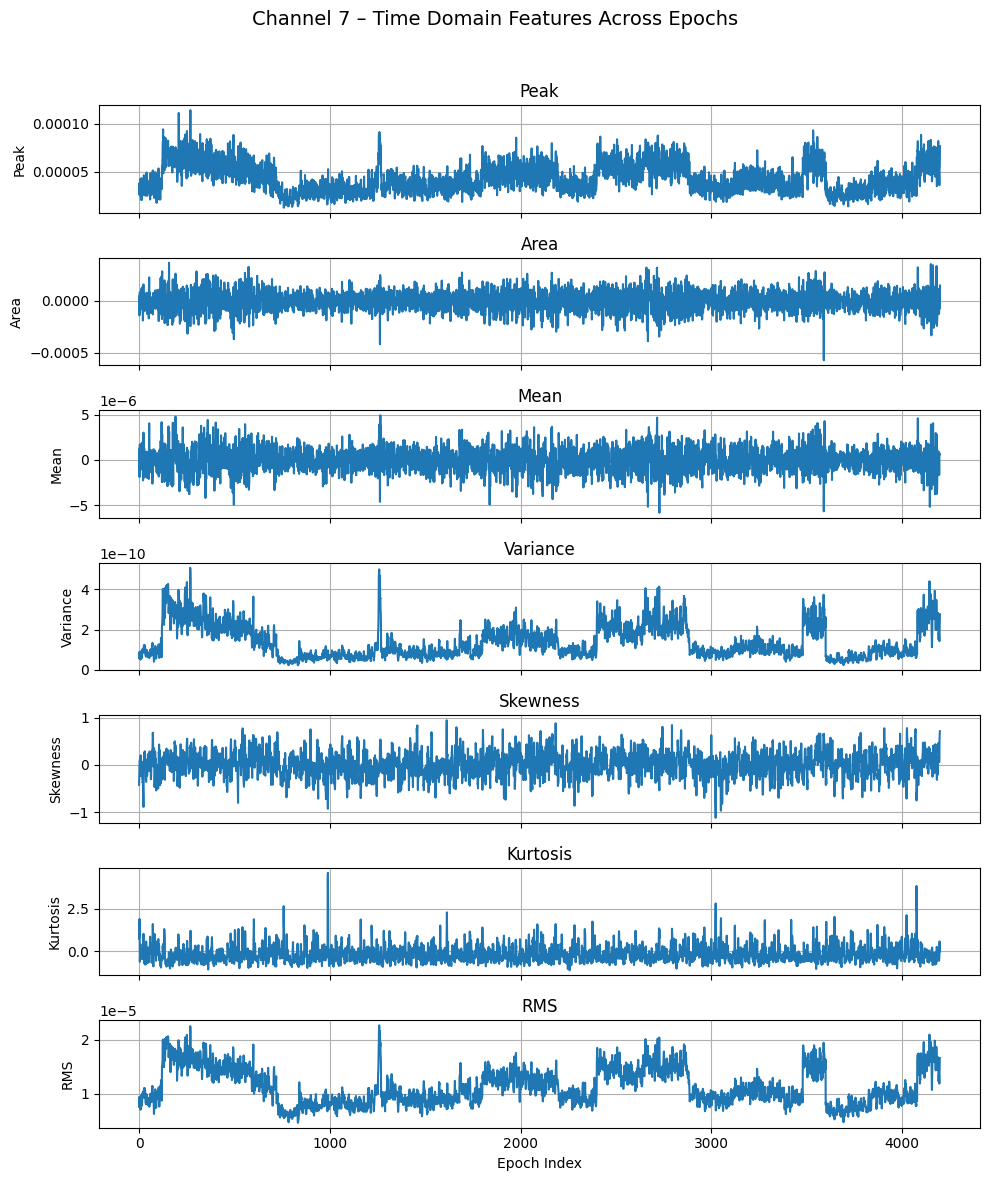

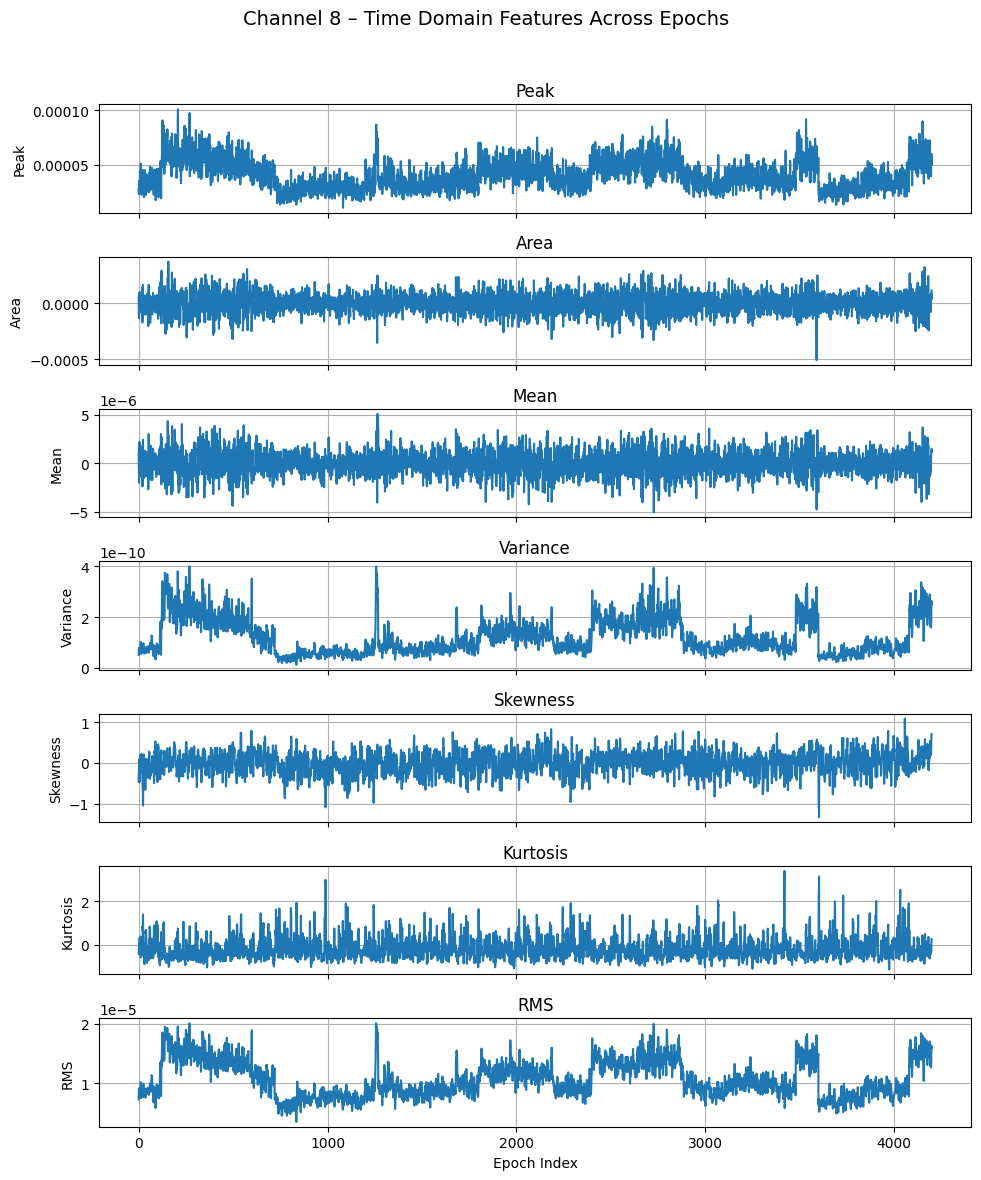

In [95]:
test = filtered_data[file_paths[0]]
features = test["Time_Domain_Features"]

n_features_per_channel = 7
feature_names = ['Peak', 'Area', 'Mean', 'Variance', 'Skewness', 'Kurtosis', 'RMS']
n_channels = features.shape[1] // n_features_per_channel
n_epochs = features.shape[0]

# Reshape to (n_epochs, n_channels, n_features_per_channel)
features_reshaped = features.reshape(n_epochs, n_channels, n_features_per_channel)

# Plot per channel: each channel gets one figure with 7 subplots
for ch in range(n_channels):
    fig, axs = plt.subplots(n_features_per_channel, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(f"Channel {ch + 1} – Time Domain Features Across Epochs", fontsize=14)

    for feat_idx, feat_name in enumerate(feature_names):
        feat_data = features_reshaped[:, ch, feat_idx]  # shape: (n_epochs,)
        axs[feat_idx].plot(feat_data, label=f'{feat_name}')
        axs[feat_idx].set_ylabel(feat_name)
        axs[feat_idx].set_title(feat_name)
        axs[feat_idx].grid(True)

    axs[-1].set_xlabel("Epoch Index")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [101]:
from scipy.signal import welch
import numpy as np

def extract_freq_domain_features(epochs, sfreq=256):

    data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
    n_epochs, n_channels, n_times = data.shape

    # Define EEG frequency bands
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30)
    }

    # Prepare feature matrix
    feature_matrix = []

    for epoch in data:
        epoch_features = []
        for ch_data in epoch:
            # Compute power spectral density using Welch's method
            freqs, psd = welch(ch_data, sfreq, nperseg=min(512, len(ch_data)))

            # Band power features
            for band_range in bands.values():
                idx_band = np.logical_and(freqs >= band_range[0], freqs < band_range[1])
                band_power = np.sum(psd[idx_band])  # area under PSD curve
                epoch_features.append(band_power)

        feature_matrix.append(epoch_features)

    return np.array(feature_matrix)

for file_path, data in filtered_data.items():
    if data["Epochs"] is not None:
        epochs = data["Epochs"]
        freq_domain_features = extract_freq_domain_features(epochs)


        filtered_data[file_path]["Freq_Domain_Features"] = freq_domain_features

# Check filtered EEG signals from the first file
filtered_data[file_paths[0]]

{'X': array([[ -1.21978372,  -0.32769319,  -1.21995831, ...,  -2.65680554,
           7.37202505,  -0.27890203],
        [ -1.42616224,  -4.18996393,  -5.65458822, ...,  -9.45534598,
          -3.67053188,  -5.48506363],
        [ -1.31524453,  -6.87075831,  -8.55992067, ..., -14.26798757,
         -11.63200572,  -8.92900433],
        ...,
        [ -3.96511643,   5.70748743,   1.11047492, ...,  -5.27998942,
           9.13724881,  -0.85580654],
        [ -0.5562302 ,   6.01519786,   3.32213104, ...,  -0.67030739,
           8.2749988 ,   2.10576813],
        [  4.22622461,   6.77563943,   6.12924025, ...,   5.20342677,
           6.29436858,   6.15256883]]),
 'Y': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
 'Y_stim': array([[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]], dtype=int16),
 'labels': array([0, 0, 0, ..., 0, 0, 0]),
 'Time_Domain_Features': array([[ 2.19424086e-05,  1.33293905e-05,  8.20700909e-07, ...,
         -4.70675720e-01, -4.0469

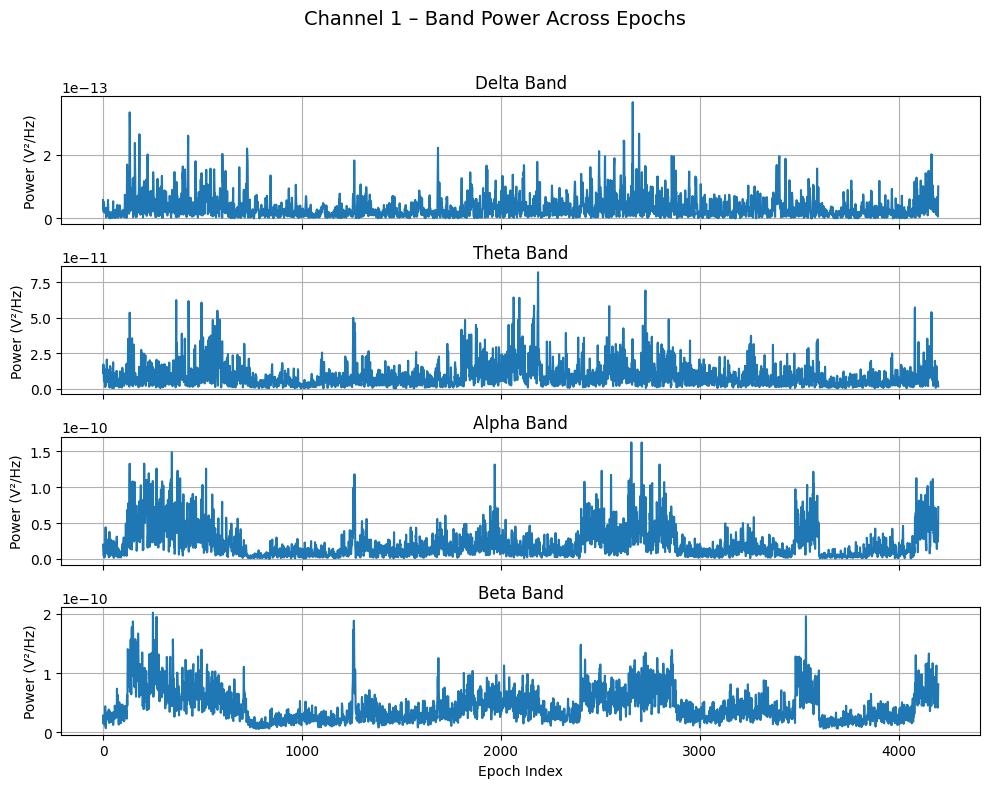

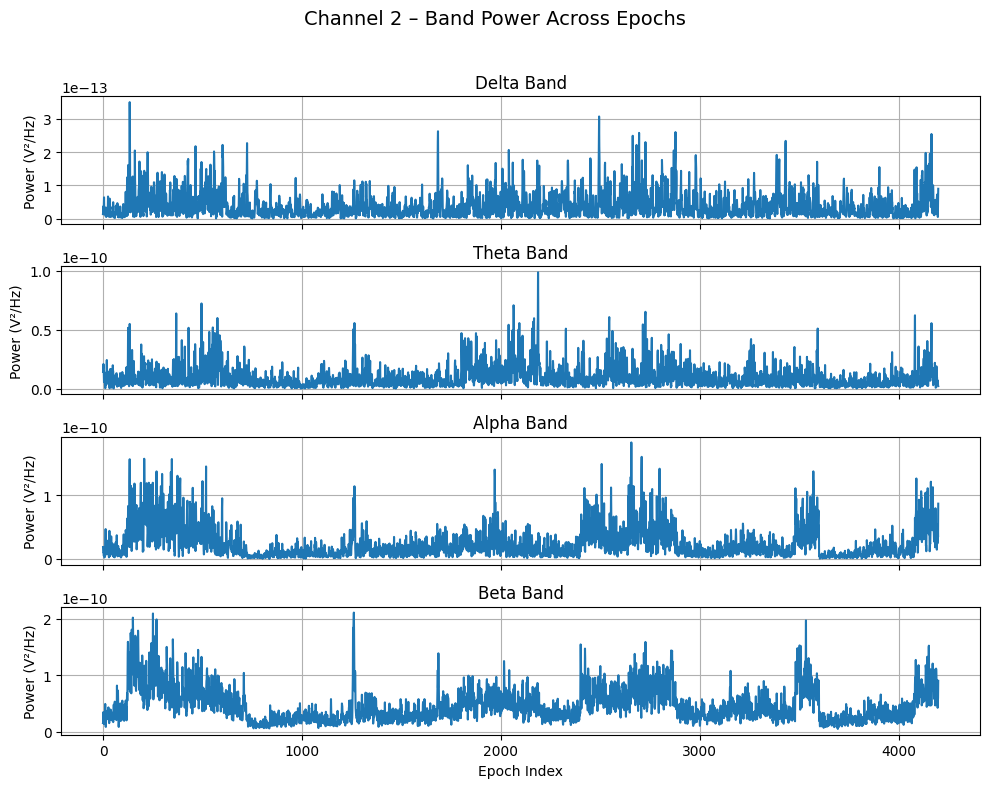

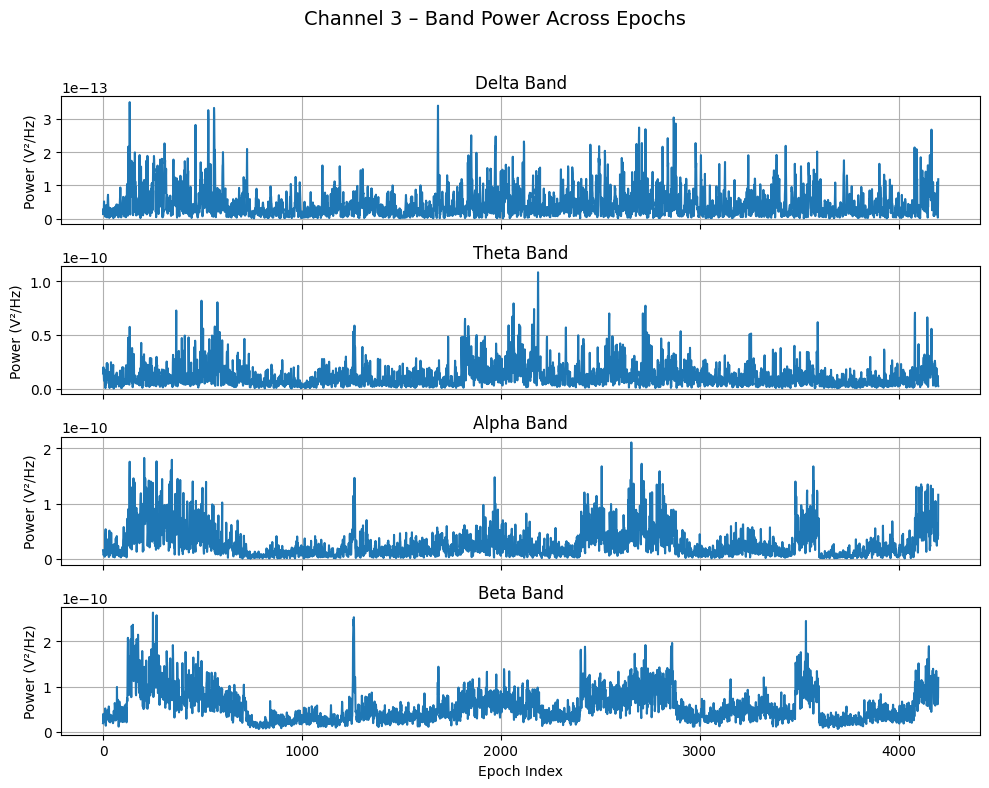

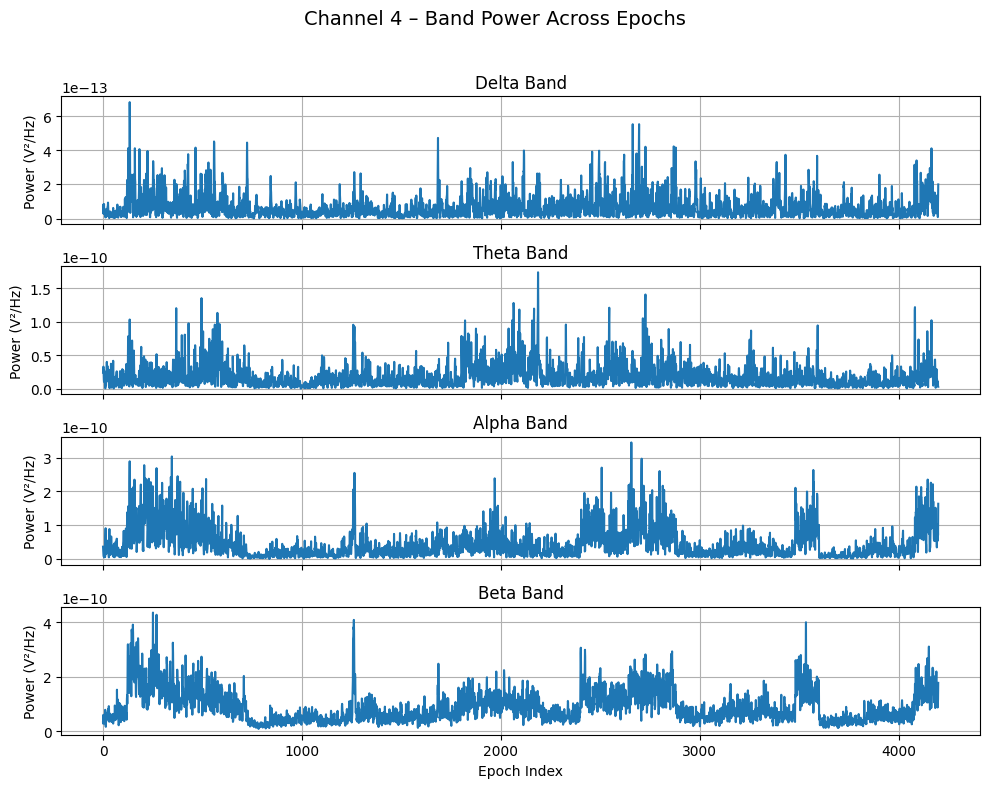

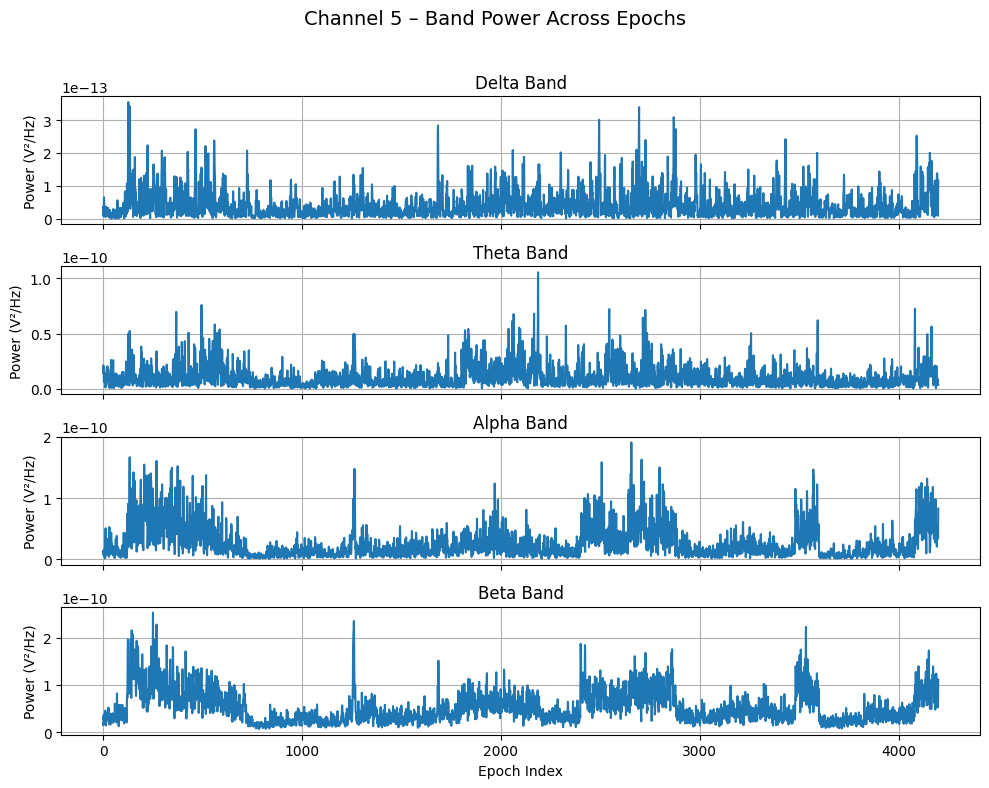

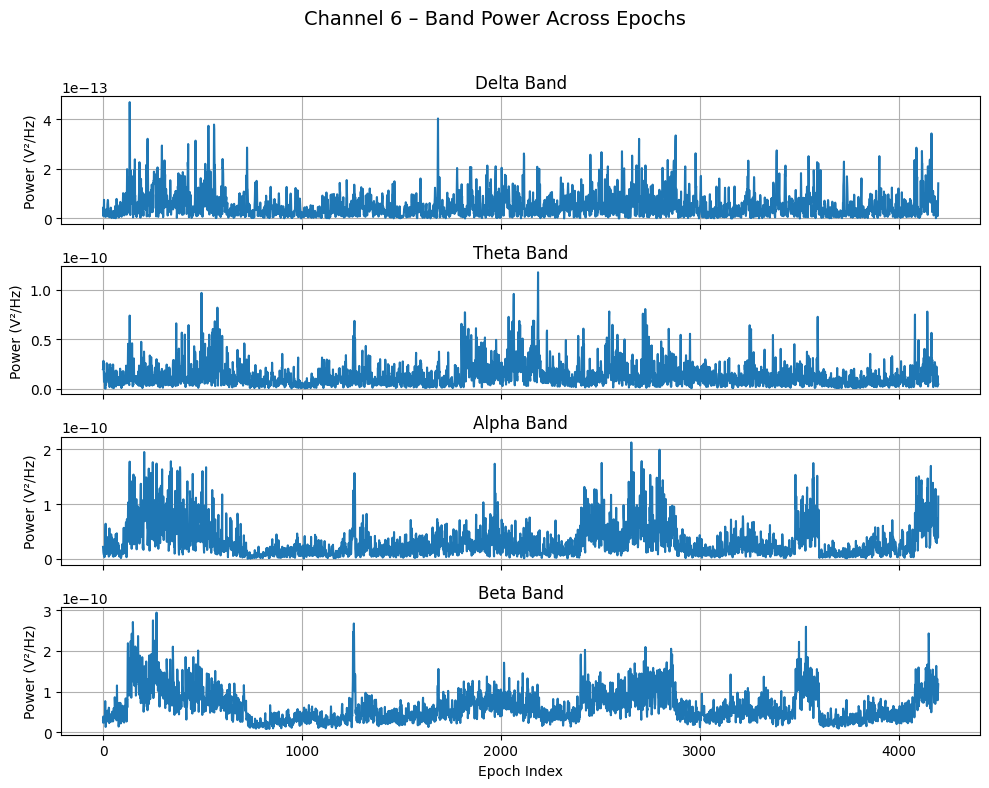

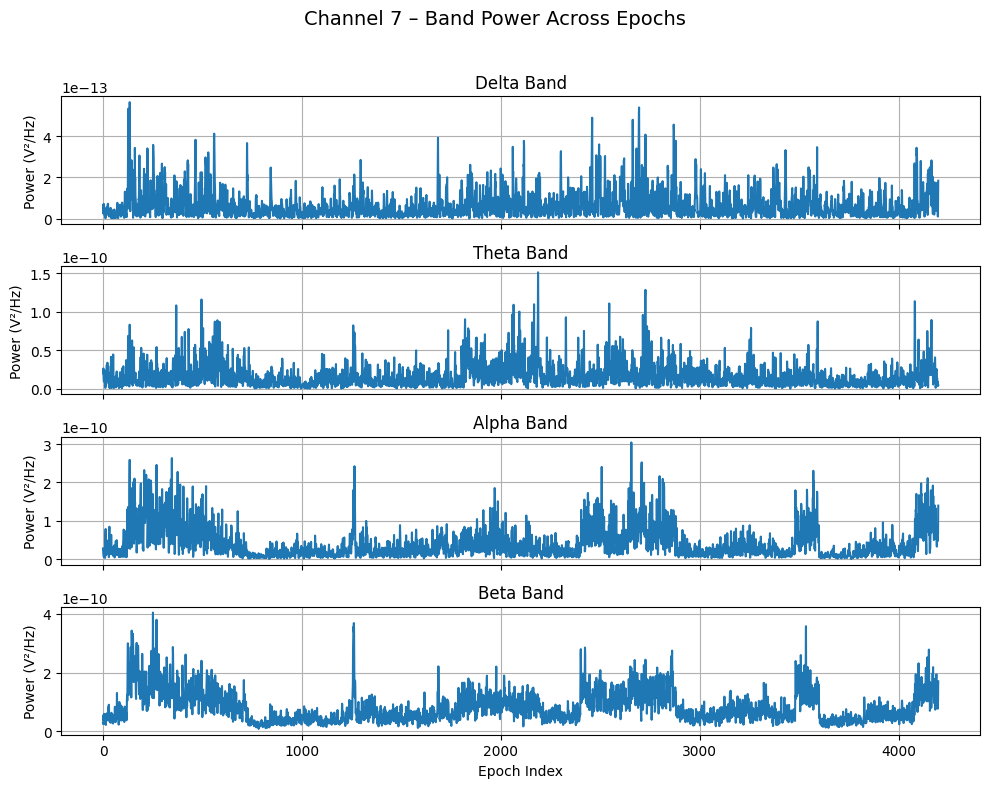

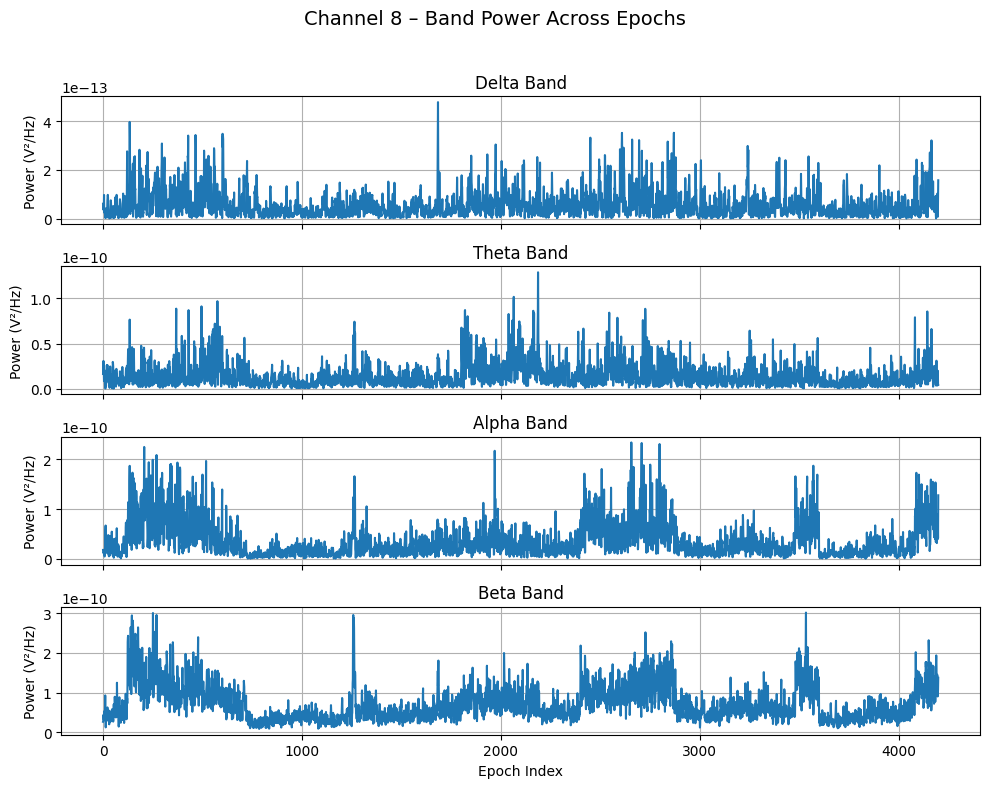

In [102]:
test = filtered_data[file_paths[0]]
X_freq = test["Freq_Domain_Features"]

# Setup
n_bands = 4
band_names = ['delta', 'theta', 'alpha', 'beta']
n_channels = X_freq.shape[1] // n_bands
n_epochs = X_freq.shape[0]

# Reshape to (n_epochs, n_channels, n_bands)
X_freq_reshaped = X_freq.reshape(n_epochs, n_channels, n_bands)

# Plot per channel: each channel gets one figure with 4 subplots
for ch in range(n_channels):
    fig, axs = plt.subplots(n_bands, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f"Channel {ch + 1} – Band Power Across Epochs", fontsize=14)

    for band_idx, band in enumerate(band_names):
        band_data = X_freq_reshaped[:, ch, band_idx]  # shape: (n_epochs,)
        axs[band_idx].plot(band_data, label=f'{band.capitalize()} Band')
        axs[band_idx].set_ylabel("Power (V²/Hz)")
        axs[band_idx].set_title(f"{band.capitalize()} Band")
        axs[band_idx].grid(True)

    axs[-1].set_xlabel("Epoch Index")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

epochs: <Epochs | 4200 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~65.9 MiB, data loaded,
 'NT': 3500
 'T': 700>
X: (347704, 8)
labels: (4200,)
Y: (347704,)
X_time: (4200, 56)
X_freq: (4200, 32)


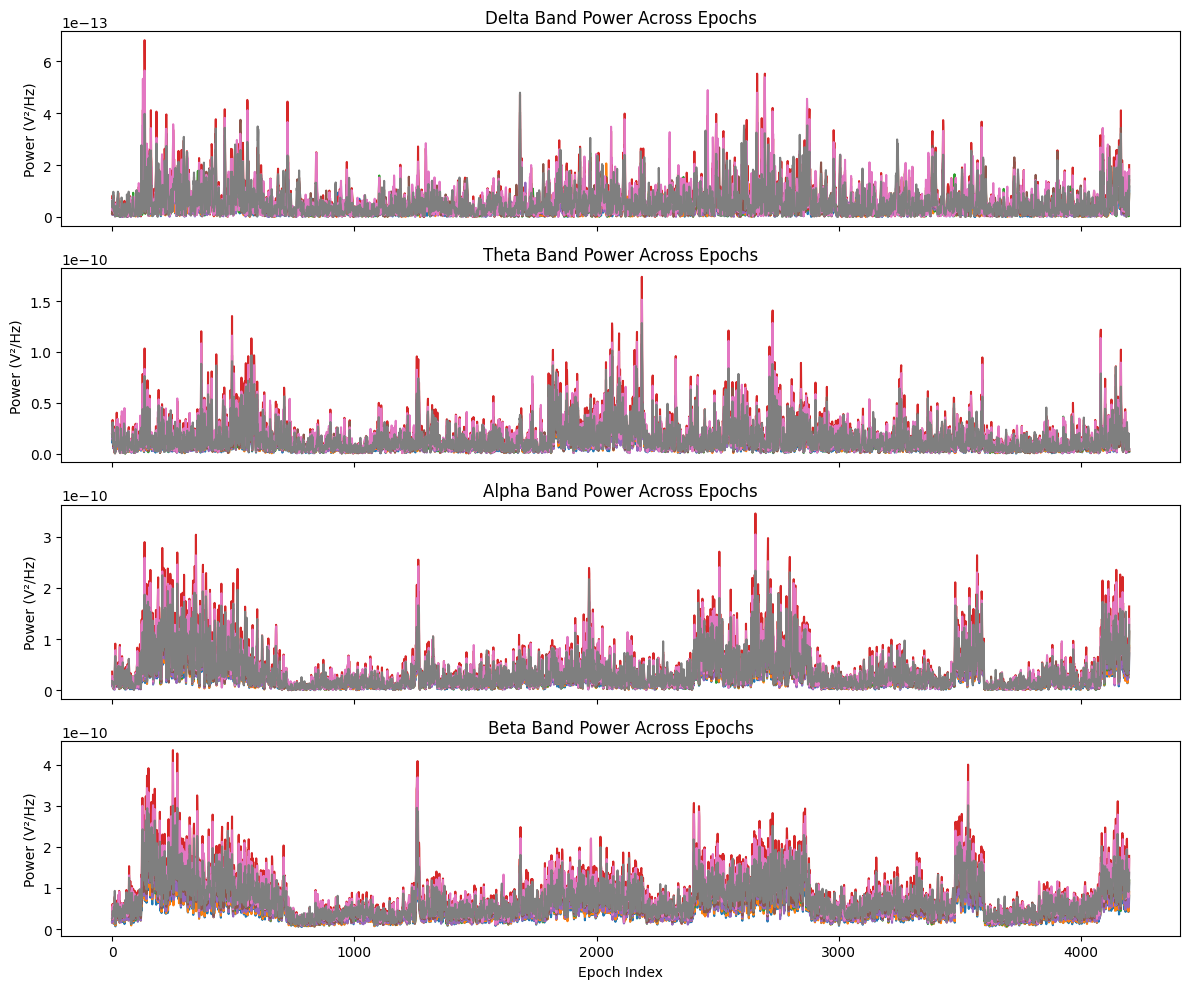

In [103]:
import matplotlib.pyplot as plt

test = filtered_data[file_paths[0]]
X_time = test["Time_Domain_Features"]
X_freq = test["Freq_Domain_Features"]
X = test["X"]
filtered_raw = test["Filtered_Raw"]
labels = test["labels"]
Y = test["Y"]
epochs = test["Epochs"]
print("epochs:",epochs)
print("X:",X.shape)
#print("filtered_raw:",filtered_raw.shape)
print("labels:",labels.shape)
print("Y:",Y.shape)
print("X_time:",X_time.shape)
print("X_freq:",X_freq.shape)

# Parameters
n_bands = 4
band_names = ['delta', 'theta', 'alpha', 'beta']
n_channels = X_freq.shape[1] // n_bands

# Reshape to (n_epochs, n_channels, n_bands)
X_freq_reshaped = X_freq.reshape(-1, n_channels, n_bands)

# Plot each frequency band separately
fig, axs = plt.subplots(n_bands, 1, figsize=(12, 10), sharex=True)

for i, band in enumerate(band_names):
    band_data = X_freq_reshaped[:, :, i]  # shape: (n_epochs, n_channels)
    axs[i].plot(band_data)
    axs[i].set_title(f"{band.capitalize()} Band Power Across Epochs")
    axs[i].set_ylabel("Power (V²/Hz)")

axs[-1].set_xlabel("Epoch Index")
plt.tight_layout()
plt.show()

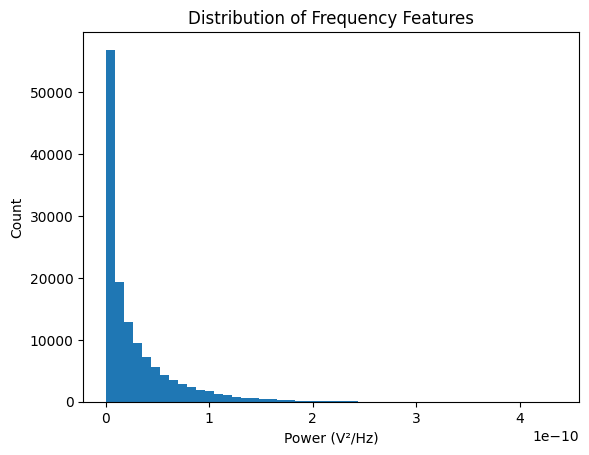

In [104]:
import matplotlib.pyplot as plt

plt.hist(X_freq.flatten(), bins=50)
plt.title("Distribution of Frequency Features")
plt.xlabel("Power (V²/Hz)")
plt.ylabel("Count")
plt.show()

/content/drive/MyDrive/A01.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A01.mat: Labels shape = (4200,)
/content/drive/MyDrive/A02.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A02.mat: Labels shape = (4200,)
/content/drive/MyDrive/A03.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A03.mat: Labels shape = (4200,)
/content/drive/MyDrive/A04.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A04.mat: Labels shape = (4200,)
/content/drive/MyDrive/A05.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A05.mat: Labels shape = (4200,)
/content/drive/MyDrive/A06.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A06.mat: Labels shape = (4200,)
/content/drive/MyDrive/A07.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A07.mat: Labels shape = (4200,)
/content/drive/MyDrive/A08.mat: Combined features shape = (4200, 88)
/content/drive/MyDrive/A08.mat: Labels shape = (4200,)


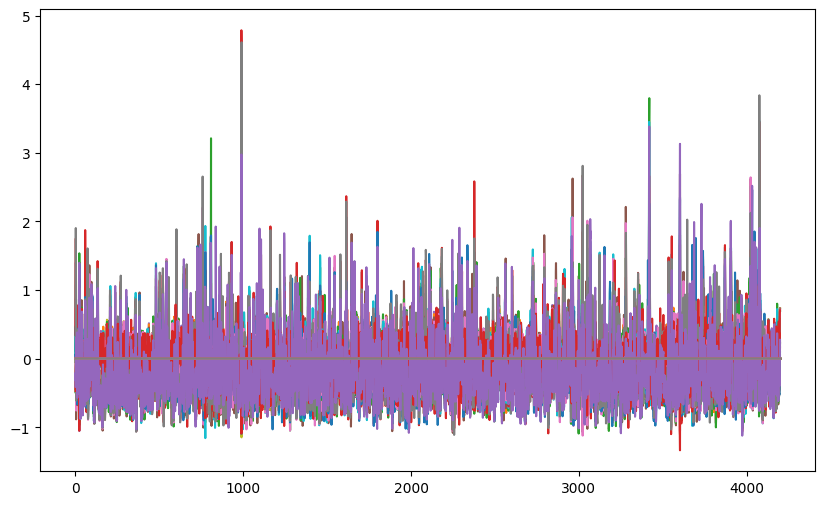

In [105]:
for file_path, data in filtered_data.items():
    if "Time_Domain_Features" in data and "Freq_Domain_Features" in data:
        time_feats = data["Time_Domain_Features"]
        freq_feats = data["Freq_Domain_Features"]
        l =  data["labels"]

        combined_feats = np.hstack((time_feats, freq_feats))

        # Save back to dict
        filtered_data[file_path]["Combined_Features"] = combined_feats

        print(f"{file_path}: Combined features shape = {combined_feats.shape}")
        print(f"{file_path}: Labels shape = {l.shape}")

test = filtered_data[file_paths[0]]
features = test["Combined_Features"]
plt.figure(figsize=(10, 6))
plt.plot(features)

In [117]:
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
from imblearn.over_sampling import SMOTE

results = {}

for file_path, data in filtered_data.items():
    X = data["Combined_Features"]
    y = data["labels"]  # Target = 1, NT = 0

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

    svm = SVC(kernel='rbf', C = 100, random_state=42)
    svm.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = svm.predict(X_test)

    # Evaluate Model Performance
    print("✅ SVM Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


✅ SVM Accuracy: 0.7464285714285714
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       713
           1       0.14      0.13      0.14       127

    accuracy                           0.75       840
   macro avg       0.49      0.49      0.49       840
weighted avg       0.74      0.75      0.74       840

✅ SVM Accuracy: 0.7642857142857142
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       713
           1       0.19      0.17      0.18       127

    accuracy                           0.76       840
   macro avg       0.52      0.52      0.52       840
weighted avg       0.75      0.76      0.76       840

✅ SVM Accuracy: 0.7428571428571429
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       713
           1       0.09      0.08      0.08       127

    accuracy                           0.74       840
   macro avg       0.47

In [116]:
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

results = {}

# Choose number of top features to keep
k = 10  # you can change this (e.g., 20, 40, etc.)

for file_path, data in filtered_data.items():
    print(f"\n📁 Processing file: {file_path}")
    X = data["Combined_Features"]
    y = data["labels"]

    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Apply SMOTE for class balancing
    sm = SMOTE(random_state=42)
    X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

    # Apply univariate feature selection (SelectKBest)
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train_smote, y_train_smote)
    X_test_selected = selector.transform(X_test)

    # Train SVM
    svm = SVC(kernel='rbf', class_weight='balanced', C=100, random_state=42)
    svm.fit(X_train_selected, y_train_smote)

    # Predict
    y_pred = svm.predict(X_test_selected)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ SVM Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


📁 Processing file: /content/drive/MyDrive/A01.mat
✅ SVM Accuracy: 0.6083
              precision    recall  f1-score   support

           0       0.85      0.65      0.73       700
           1       0.19      0.41      0.26       140

    accuracy                           0.61       840
   macro avg       0.52      0.53      0.50       840
weighted avg       0.74      0.61      0.65       840


📁 Processing file: /content/drive/MyDrive/A02.mat
✅ SVM Accuracy: 0.5321
              precision    recall  f1-score   support

           0       0.81      0.57      0.67       700
           1       0.14      0.34      0.20       140

    accuracy                           0.53       840
   macro avg       0.48      0.46      0.43       840
weighted avg       0.70      0.53      0.59       840


📁 Processing file: /content/drive/MyDrive/A03.mat
✅ SVM Accuracy: 0.5667
              precision    recall  f1-score   support

           0       0.87      0.57      0.69       700
           1   

In [ ]:
from collections import Counter
print(Counter(y_train_smote))

Counter({np.int64(0): 2787, np.int64(1): 2787})


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
from imblearn.over_sampling import SMOTE

results = {}

for file_path, data in filtered_data.items():
    X = data["Combined_Features"]
    y = data["labels"]  # Target = 1, NT = 0

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

    ntree=100
    rf = RandomForestClassifier(n_estimators=ntree, class_weight='balanced', random_state=42)
    rf.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = rf.predict(X_test)



    # Evaluate Model Performance
    print("✅ Random Forest Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


✅ Random Forest Accuracy: 0.7845953002610966
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       646
           1       0.16      0.09      0.12       120

    accuracy                           0.78       766
   macro avg       0.50      0.50      0.50       766
weighted avg       0.74      0.78      0.76       766

✅ Random Forest Accuracy: 0.799761620977354
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       699
           1       0.21      0.07      0.11       140

    accuracy                           0.80       839
   macro avg       0.52      0.51      0.50       839
weighted avg       0.73      0.80      0.76       839

✅ Random Forest Accuracy: 0.8114558472553699
              precision    recall  f1-score   support

           0       0.85      0.95      0.89       710
           1       0.16      0.05      0.08       128

    accuracy                           0.81     

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
from imblearn.over_sampling import SMOTE

results = {}

for file_path, data in filtered_data.items():
    X = data["Combined_Features"]
    y = data["labels"]  # Target = 1, NT = 0

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

    mdl_bi = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    mdl_bi.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = mdl_bi.predict(X_test)



    # Evaluate Model Performance
    print("✅ Logistic Regression Accuracy:", mdl_bi.score(X_test, y_test))
    print(classification_report(y_test, y_pred))


✅ Logistic Regression Accuracy: 0.5861618798955613
              precision    recall  f1-score   support

           0       0.86      0.61      0.71       646
           1       0.18      0.46      0.26       120

    accuracy                           0.59       766
   macro avg       0.52      0.53      0.49       766
weighted avg       0.75      0.59      0.64       766

✅ Logistic Regression Accuracy: 0.5911799761620977
              precision    recall  f1-score   support

           0       0.86      0.60      0.71       699
           1       0.21      0.53      0.30       140

    accuracy                           0.59       839
   macro avg       0.54      0.57      0.51       839
weighted avg       0.76      0.59      0.64       839

✅ Logistic Regression Accuracy: 0.5346062052505967
              precision    recall  f1-score   support

           0       0.84      0.56      0.67       710
           1       0.14      0.41      0.21       128

    accuracy                 

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
from imblearn.over_sampling import SMOTE

results = {}

for file_path, data in filtered_data.items():
    X = data["Combined_Features"]
    y = data["labels"]  # Target = 1, NT = 0

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

    mdl_mult = LogisticRegression(multi_class='multinomial', class_weight='balanced', random_state=42, max_iter=1000)
    mdl_mult.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = mdl_mult.predict(X_test)



    # Evaluate Model Performance
    print("✅ Multimodal Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Multimodal Logistic Regression Accuracy: 0.5900783289817232
              precision    recall  f1-score   support

           0       0.86      0.62      0.72       646
           1       0.18      0.45      0.26       120

    accuracy                           0.59       766
   macro avg       0.52      0.53      0.49       766
weighted avg       0.75      0.59      0.64       766



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Multimodal Logistic Regression Accuracy: 0.5899880810488677
              precision    recall  f1-score   support

           0       0.86      0.60      0.71       699
           1       0.21      0.53      0.30       140

    accuracy                           0.59       839
   macro avg       0.54      0.57      0.51       839
weighted avg       0.76      0.59      0.64       839



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


...

✅ Multimodal Logistic Regression Accuracy: 0.6166666666666667
              precision    recall  f1-score   support

           0       0.86      0.64      0.74       697
           1       0.22      0.50      0.31       143

    accuracy                           0.62       840
   macro avg       0.54      0.57      0.52       840
weighted avg       0.75      0.62      0.66       840



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Multimodal Logistic Regression Accuracy: 0.6114457831325302
              precision    recall  f1-score   support

           0       0.86      0.64      0.74       561
           1       0.19      0.45      0.26       103

    accuracy                           0.61       664
   macro avg       0.52      0.54      0.50       664
weighted avg       0.76      0.61      0.66       664



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Multimodal Logistic Regression Accuracy: 0.6178571428571429
              precision    recall  f1-score   support

           0       0.86      0.65      0.74       697
           1       0.22      0.48      0.30       143

    accuracy                           0.62       840
   macro avg       0.54      0.56      0.52       840
weighted avg       0.75      0.62      0.66       840

